# Clustering - Kümeleme

In [1]:
import pandas as pd  # Veri analizi ve tablo işlemleri için pandas kütüphanesi

pd.set_option('display.max_columns', 100)  # DataFrame yazdırırken en fazla 100 sütun göster

import warnings  # Python uyarı (warning) mesajlarını yönetmek için kullanılır
warnings.filterwarnings('ignore')  # Uyarı mesajlarını ekranda göstermeyi kapat

import matplotlib.pyplot as plt  # Grafik çizmek için temel görselleştirme kütüphanesi
import seaborn as sns  # Daha estetik ve gelişmiş veri görselleştirme kütüphanesi

In [2]:
df = pd.read_excel('cars.xls')

In [ ]:
# Regression → başarı metriği: R² (R-squared)
# Modelin veriyi ne kadar iyi açıkladığını gösterir (0-1 arası, 1'e yakınsa iyi)

# Classification → başarı metrikleri:
# Accuracy  → genel doğruluk oranı
# Precision → modelin "1" dediği ne kadar doğru
# Recall    → gerçek "1" olanları ne kadar yakaladı
# F1-score  → precision ve recall'un dengeli ortalaması

# Clustering → klasik "accuracy" yoktur ❌
# Çünkü gerçek etiket (label) yoktur

# Bunun yerine:
# Silhouette Score kullanılır ✔
# -1 ile 1 arasında değer alır
# 1'e yakın → kümeler iyi ayrılmış
# 0 → kümeler iç içe
# -1 → yanlış kümelenmiş

In [3]:
x = df[['Price', 'Mileage', 'Cylinder']] 

In [5]:
x.head()

,Price,Mileage,Cylinder
0,17314.103129,8221,6
1,17542.036083,9135,6
2,16218.847862,13196,6
3,16336.913140,16342,6
4,16339.170324,19832,6


In [6]:
from sklearn.cluster import KMeans  
# K-Means kümeleme (clustering) algoritmasını içe aktarır

from sklearn.metrics import silhouette_score  
# Kümeleme başarısını ölçmek için silhouette score fonksiyonunu içe aktarır

In [7]:
model=KMeans(4)

In [8]:
model.fit(x)

KMeans(n_clusters=4)

In [9]:
tahmin=model.predict(x)

In [10]:
tahmin

array([0, 0, 0, 3, 3, 3, 3, 3, 3, 1, 0, 3, 3, 3, 3, 3, 1, 1, 1, 1, 0, 0,
       0, 3, 3, 3, 3, 3, 1, 1, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 0, 0, 3, 3,
       3, 3, 1, 1, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 0, 0, 3, 3, 3, 3,
       1, 1, 1, 1, 0, 0, 0, 0, 2, 3, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 0, 3, 3, 3, 3, 3, 3, 1, 1, 0, 0, 0, 0, 3, 3,
       3, 3, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 0, 0, 3, 3, 3, 3, 3, 3,
       1, 1, 0, 0, 0, 3, 3, 3, 3, 3, 3, 1, 0, 3, 3, 3, 3, 3, 3, 3, 1, 1,
       0, 3, 3, 3, 3, 3, 3, 1, 1, 1, 0, 0, 3, 3, 3, 3, 3, 3, 3, 1, 0, 0,
       0, 3, 3, 3, 3, 3, 1, 1, 0, 0, 0, 3, 3, 3, 3, 3, 3, 1, 0, 0, 3, 3,
       3, 3, 3, 3, 3, 1, 0, 3, 3, 3, 3, 3, 3, 3, 1, 1, 0, 0, 3, 3, 3, 3,
       3, 3, 1, 1, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 0,

<Axes: ylabel='count'>

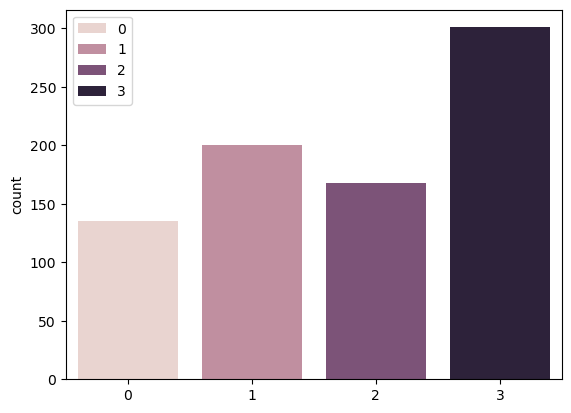

In [12]:
sns.countplot(x=tahmin, hue=tahmin)

In [13]:
x['cluster']=tahmin

In [15]:
x.sample(5)

,Price,Mileage,Cylinder,cluster
611,16353.096517,16078,4,3
180,11031.129931,20156,4,3
297,11961.619958,27394,4,1
473,22470.358430,22626,6,3
476,21525.339008,25020,6,1


In [16]:
silhouette_score(x, tahmin)

np.float64(0.3381980274495343)

Text(0, 0.5, 'fiyat')

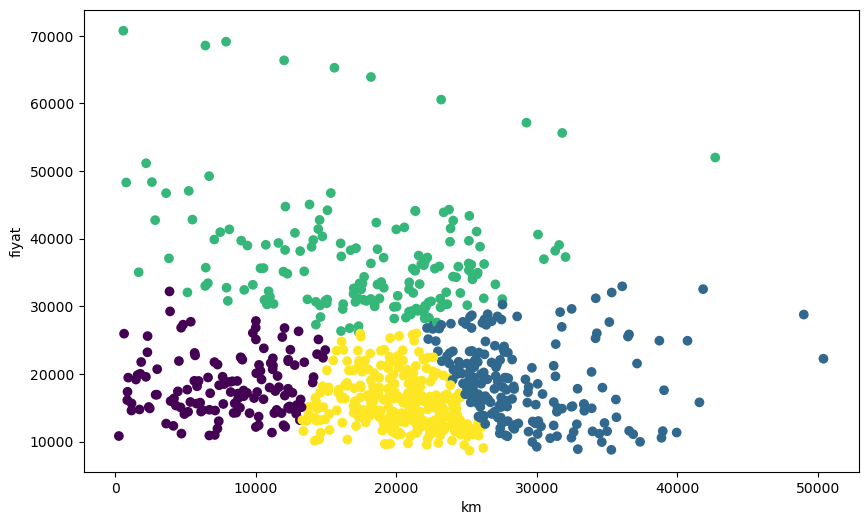

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(x.Mileage, x.Price, c=tahmin)
plt.xlabel("km")
plt.ylabel('fiyat')

In [18]:
#wcss= within cluster sum of squares
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    tahmin=model.predict(x)
    ss1=silhouette_score(x,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.4515070123539653
0.4148818525042739
0.4132860884357308
0.35258621544927415
0.3409658922510661
0.3570816974532407
0.33810392867962513
0.3432551775148514


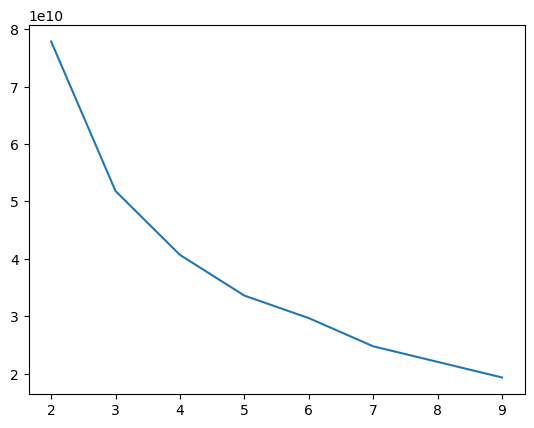

In [19]:
plt.plot(range(2,10),wcss)

In [20]:
from yellowbrick.cluster import KElbowVisualizer

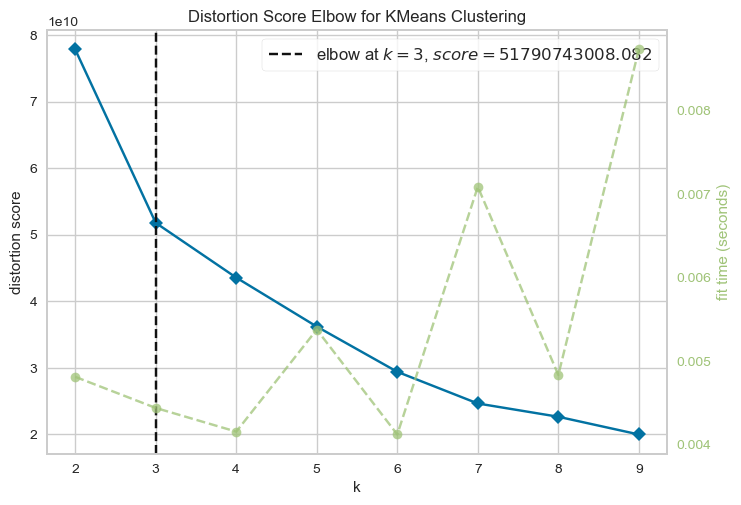

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [21]:
vis = KElbowVisualizer(KMeans(), k=(2,10))
vis.fit(x)
vis.show()

# Hierarchical Clustering

##### 👉 Veriyi hiyerarşik olarak kümelere ayırmak için bağlantı (distance) hesaplar
##### Küçük kümeleri birleştirerek büyük kümeler oluşturur
##### Cluster ağacı (dendrogram) için temel yapı

In [25]:
from scipy.cluster.hierarchy import dendrogram, linkage
# Hierarchical (hiyerarşik) kümeleme için gerekli fonksiyonları içe aktarır

In [23]:
data=linkage(x,method='ward',metric='euclidean')

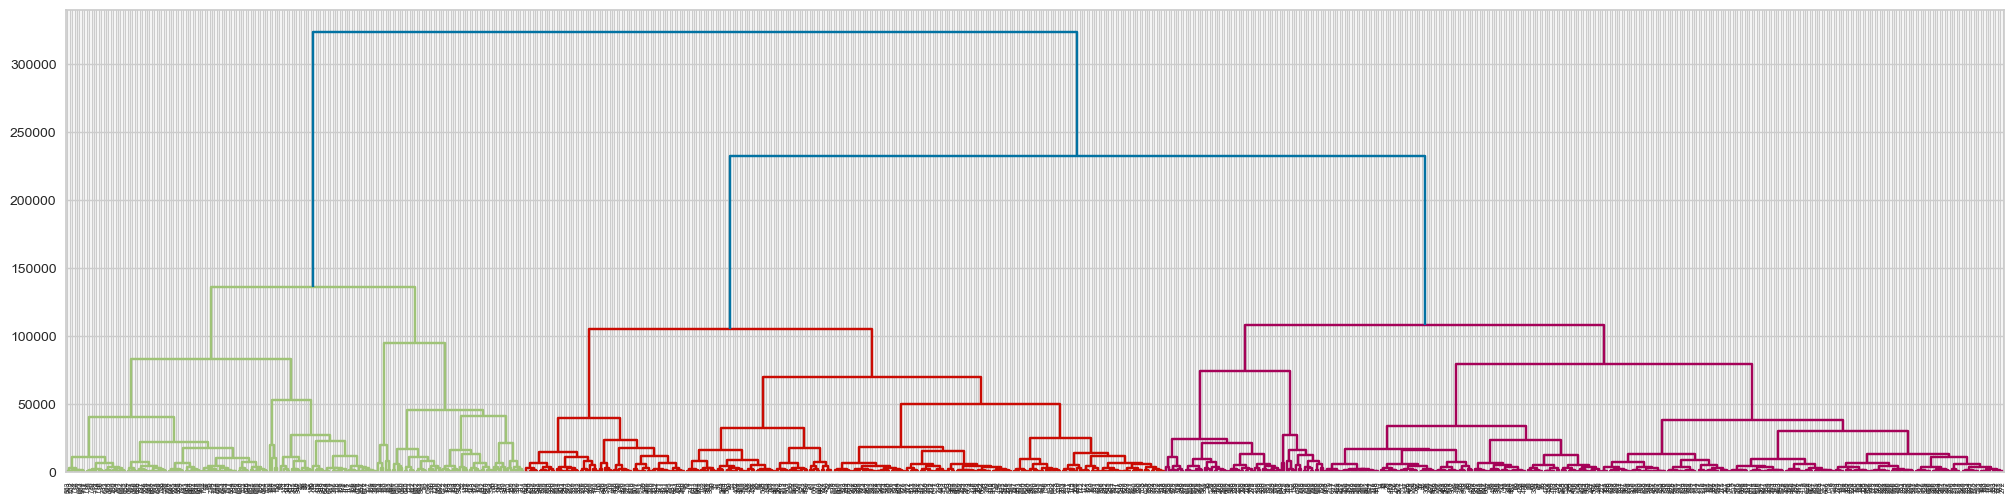

In [24]:
plt.figure(figsize=(25,6))
dendrogram(data);
plt.savefig('x.png')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


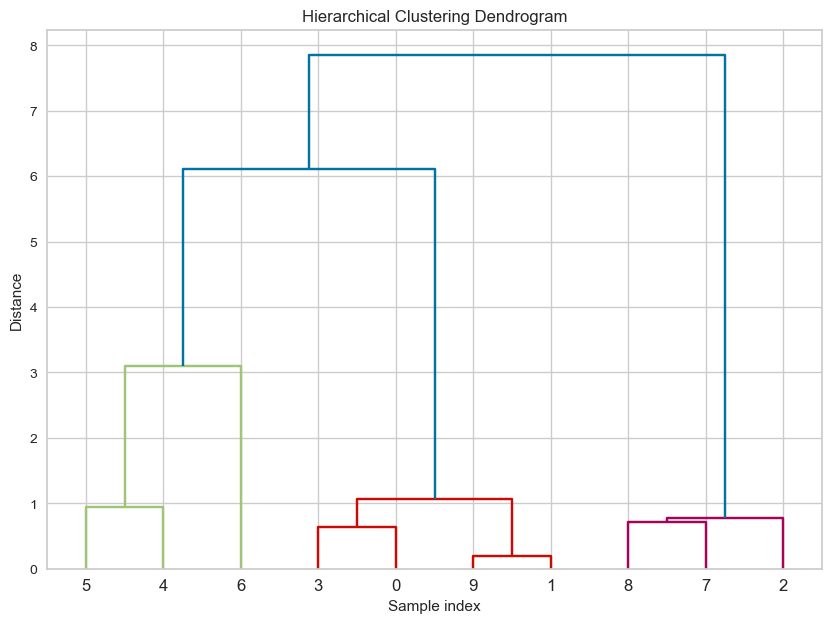

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate sample data
X, _ = make_blobs(n_samples=10, centers=3, cluster_std=0.60, random_state=0)

# Perform hierarchical clustering
linked = linkage(X, 'ward')

# Create a dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
📌 DBSCAN nedir?

👉 DBSCAN, yoğunluğa (density) göre veri kümelerini bulan bir clustering algoritmasıdır.

🧠 Temel fikir:

👉 Birbirine yakın (yoğun) noktaları küme yapar
👉 Seyrek noktaları outlier (gürültü) olarak bırakır

📊 DBSCAN’in en önemli özelliği:

✔ Küme sayısını sen vermezsin
✔ Model kendi kümeyi bulur
✔ Outlier (noise) tespit eder

In [27]:
from sklearn.cluster import DBSCAN

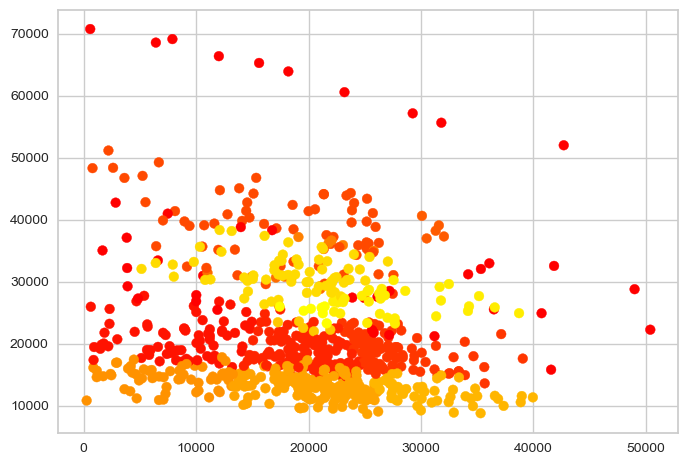

In [28]:
db=DBSCAN(min_samples=5)
from sklearn.preprocessing import StandardScaler
x2=StandardScaler().fit_transform(x)
y=db.fit_predict(x2)

plt.scatter(x['Mileage'],x['Price'],c=y,cmap='autumn');
plt.savefig('clustering.png', dpi=300)

# Agglomerative Clustering (Aşağıdan yukarıya hiyerarşik kümeleme)

👉 Agglomerative Clustering, hiyerarşik kümelemenin en yaygın türüdür.

🧠 Nasıl çalışır?

👉 “Bottom-up” (aşağıdan yukarıya) yaklaşım kullanır:

Her veri noktası başlangıçta tek bir kümedir
En benzer iki nokta birleştirilir
Bu işlem tekrar eder
En sonunda tek bir büyük küme oluşur
🌳 Mantık:
Başlangıç:  [A] [B] [C] [D]

1. Adım:    [AB] [C] [D]
2. Adım:    [AB] [CD]
3. Adım:    [ABCD]

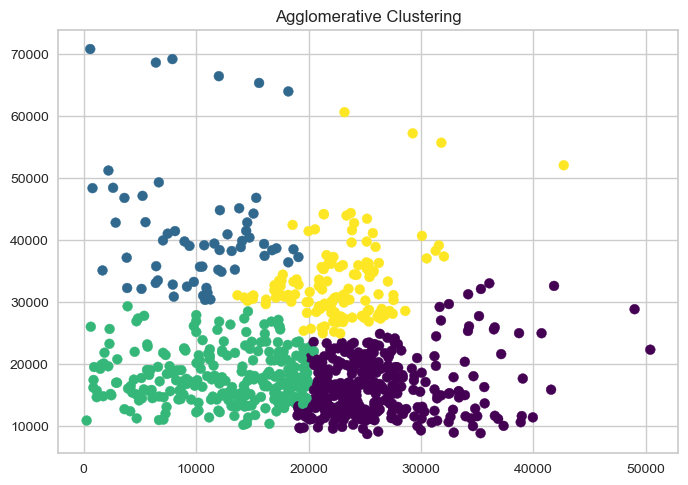

In [30]:
from sklearn.cluster import AgglomerativeClustering
agg_clustering = AgglomerativeClustering(n_clusters=4)
y_agg = agg_clustering.fit_predict(x)

# Plot the results
plt.scatter(x.Mileage, x.Price, c=y_agg, s=50, cmap='viridis')
plt.title("Agglomerative Clustering")
plt.show()

In [31]:
df=pd.read_csv('Billionaires.csv')

In [32]:
df.head()

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,organization,selfMade,status,gender,birthDate,lastName,firstName,title,date,state,residenceStateRegion,birthYear,birthMonth,birthDay,cpi_country,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,LVMH Moët Hennessy Louis Vuitton,False,U,M,3/5/1949 0:00,Arnault,Bernard,Chairman and CEO,4/4/2023 5:01,NaN,NaN,1949.0,3.0,5.0,110.05,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,Tesla,True,D,M,6/28/1971 0:00,Musk,Elon,CEO,4/4/2023 5:01,Texas,South,1971.0,6.0,28.0,117.24,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,Amazon,True,D,M,1/12/1964 0:00,Bezos,Jeff,Chairman and Founder,4/4/2023 5:01,Washington,West,1964.0,1.0,12.0,117.24,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,Oracle,True,U,M,8/17/1944 0:00,Ellison,Larry,CTO and Founder,4/4/2023 5:01,Hawaii,West,1944.0,8.0,17.0,117.24,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,Berkshire Hathaway Inc. (Cl A),True,D,M,8/30/1930 0:00,Buffett,Warren,CEO,4/4/2023 5:01,Nebraska,Midwest,1930.0,8.0,30.0,117.24,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


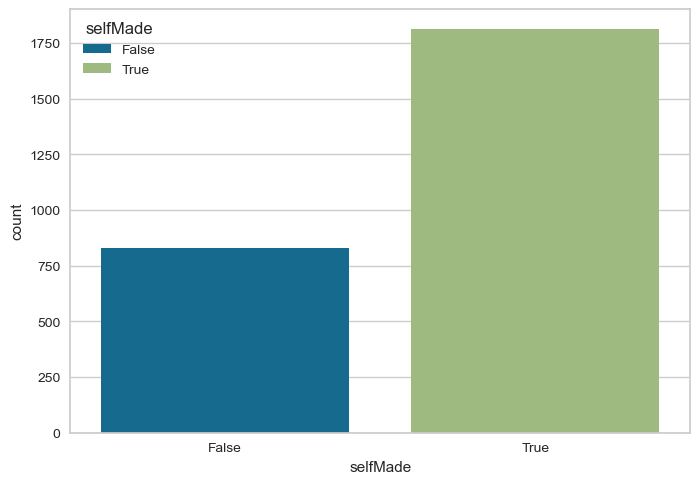

In [33]:
sns.countplot(x=df['selfMade'], hue=df['selfMade']);

In [34]:
tr=df[df['country']=='Turkey']

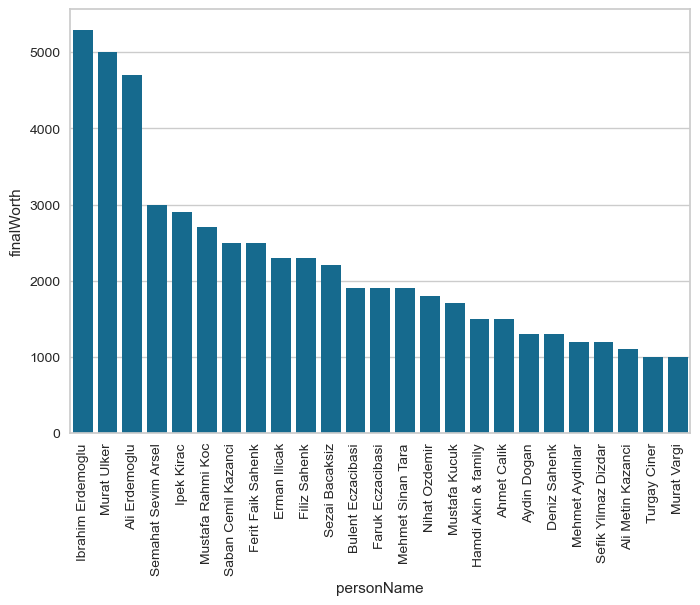

In [35]:
sns.barplot(x=tr['personName'],y=tr['finalWorth'])
plt.xticks(rotation=90);

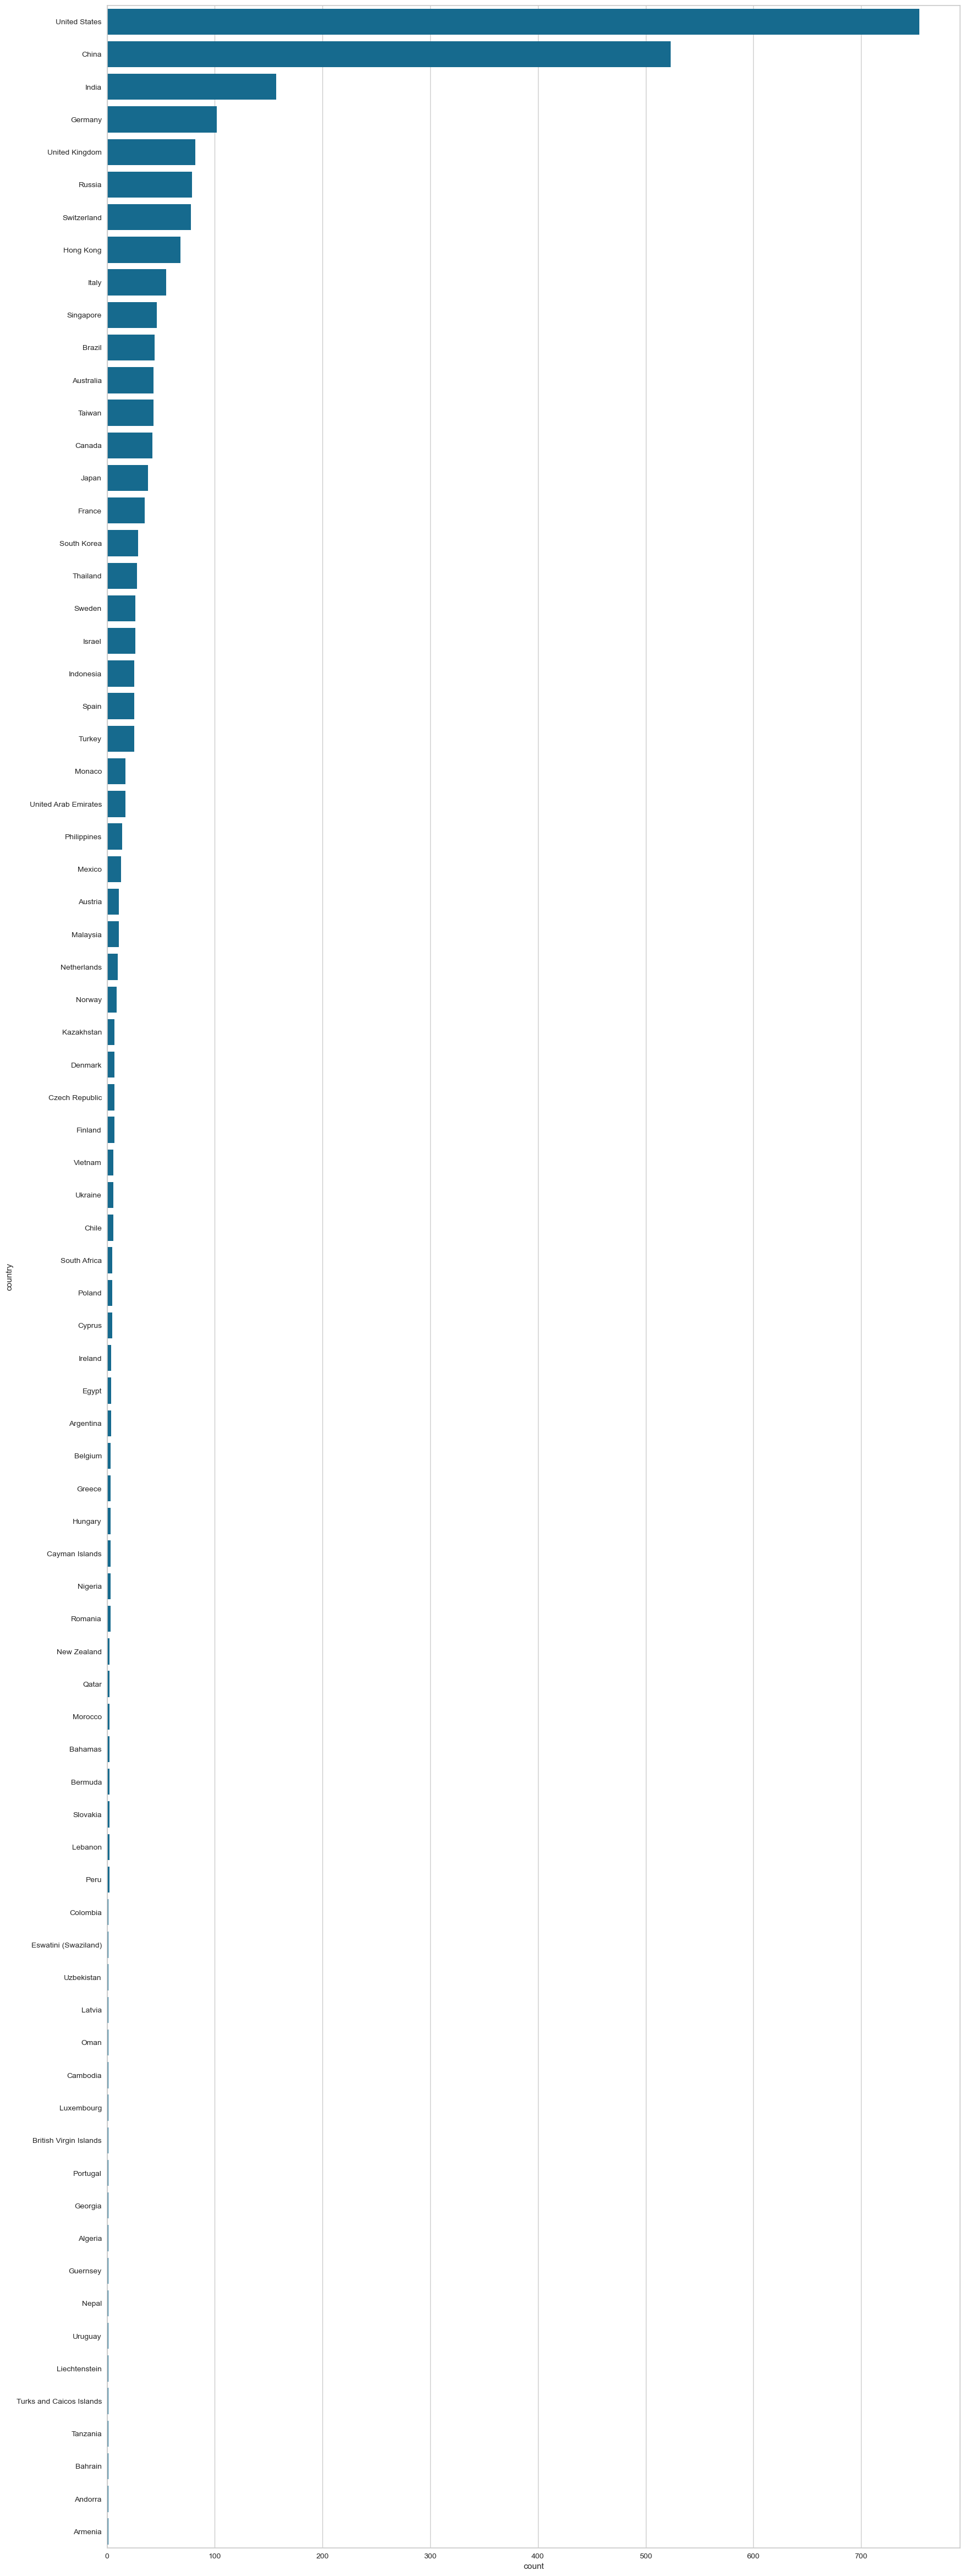

In [37]:
ydf=df['country'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(20,60))
sns.countplot(y=df['country'],order=ydf.index);

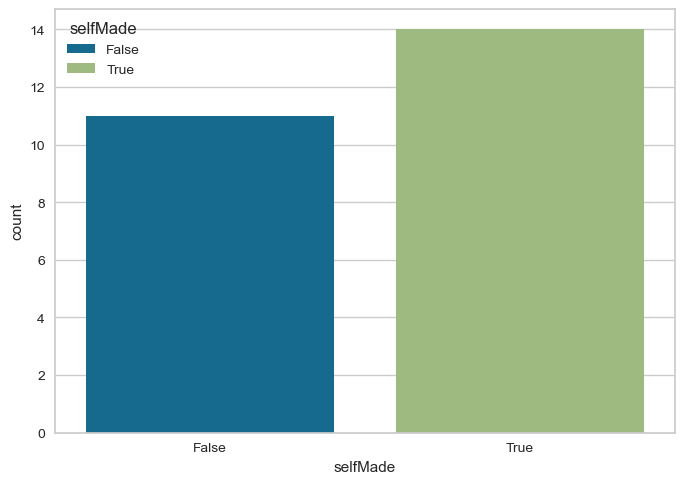

In [36]:
sns.countplot(x=tr['selfMade'], hue=df['selfMade']);

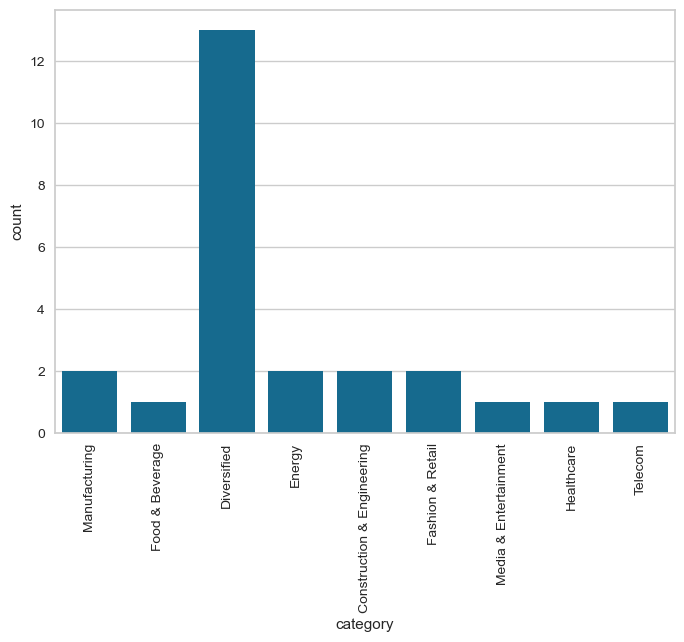

In [38]:
sns.countplot(x=tr['category'])
plt.xticks(rotation=90)
plt.show()

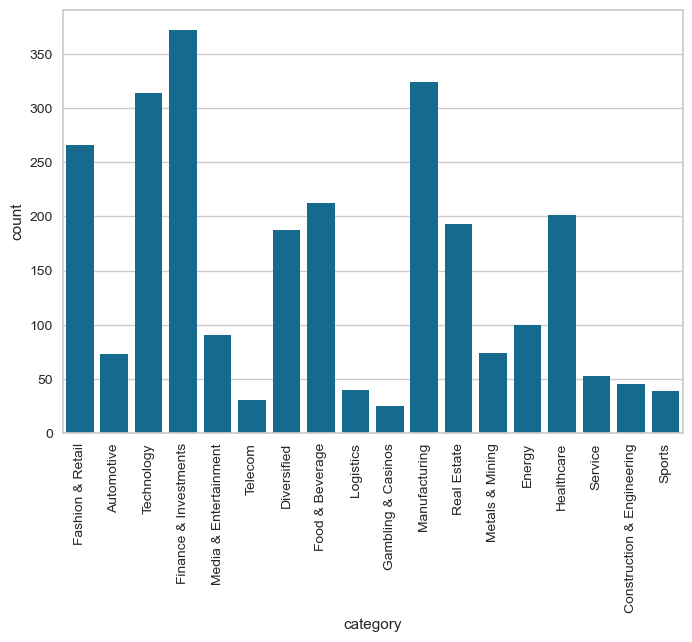

In [39]:
sns.countplot(x=df['category'])
plt.xticks(rotation=90)
plt.show()

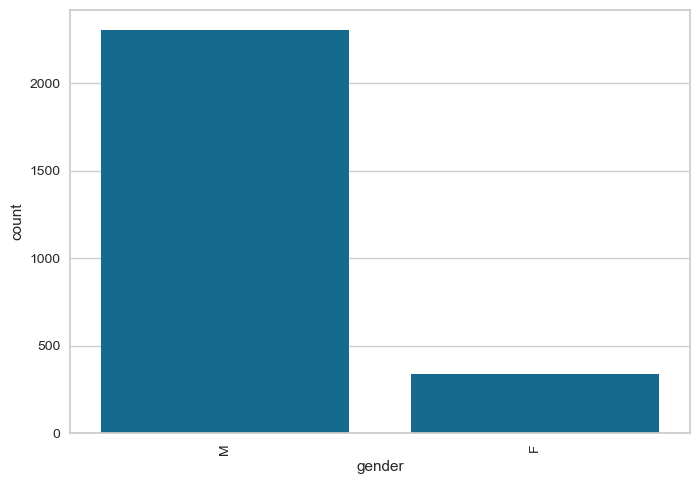

In [41]:
sns.countplot(x=df['gender'])
plt.xticks(rotation=90)
plt.show()

In [42]:
df['gender'].value_counts()

gender
M    2303
F     337
Name: count, dtype: int64

In [43]:
kore =df[df['country']=='Kore']

<Axes: >

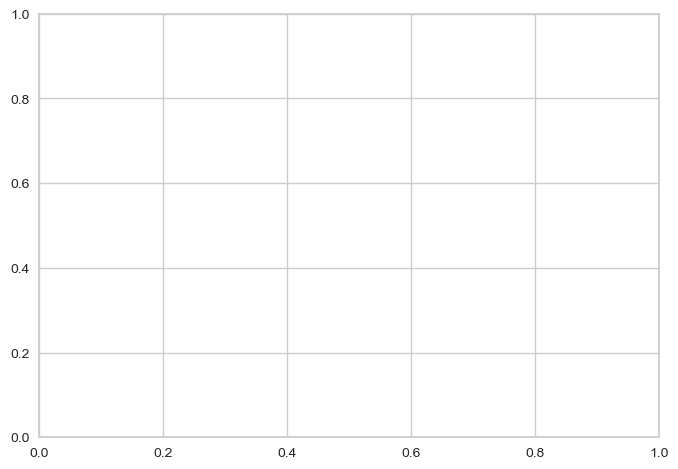

In [45]:
sns.countplot(x=kore['gender'])

<Axes: xlabel='gender', ylabel='count'>

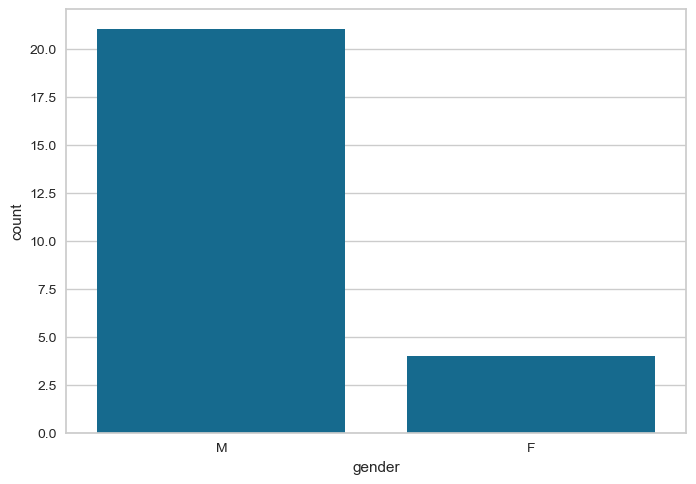

In [46]:
sns.countplot(x=tr['gender'])

In [47]:
tr['gender'].value_counts()

gender
M    21
F     4
Name: count, dtype: int64